This is a script to calculate vigilance within fMRI epochs, while examining the effect of conservative or aggressive IC component removal and high-motion time points on vigilance calculation.

Author: Mary Miedema, 2025

Configure script, then calculate vigilance (excluding bad time points):

In [ ]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt
from scipy.io import savemat

input_root = 'E://eeg_pipeline//MNE_postICA//'
output_root = 'E://eeg_pipeline//EEG_measures//'
fig_root = 'E://eeg_pipeline//QC_plots//'

TR = 1030 # msec
task_id = 'breathing'
my_subs = ['0059','0134','0704','1092','1693','1750','2888','3046','5262','5571','5931','6173','6293','7002','7712','7994','8116','8223','8420','8803','8907','9877','9922'] 
my_subs = ['0059','0704','1092','1693','1750','2888','3046','4901','5262','5571','5931','6173','6293','7002','7712','7994','8116','8420','8907','9877']

tr_len = 395 #395 for breathing, 595 for rest

vigilance_ts = np.zeros((len(my_subs),tr_len,2))
bad_epoch_labels = np.zeros((len(my_subs),tr_len,2))

for s_i in range(len(my_subs)):
    sub_i = my_subs[s_i]
    for ica_opt in range(2):
        if ica_opt == 0:
            eeg_fname = input_root+sub_i+'_'+task_id+'_ica_corr.fif'
            strategy = 'aggressive'
        elif ica_opt == 1:
            eeg_fname = input_root+sub_i+'_'+task_id+'_ica_corr_conservative.fif'
            strategy = 'conservative'
    
        # load in data
        corr = mne.io.read_raw(eeg_fname, preload=True,verbose=40)
        
        # epoch using TRs
        epochs = mne.make_fixed_length_epochs(corr, duration=TR/1000, preload=True,reject_by_annotation=False,verbose=False)
        
        # mark bad epochs (containing times above rms threshold)
        # first get rms threshold from corrected data
        rms = np.sqrt(np.mean(np.square(corr._data),axis=0))
        rms_med = np.median(rms)
        q1 = np.percentile(rms, 25)
        q3 = np.percentile(rms, 75)
        iqr = q3 - q1
        rms_thresh = rms_med + 6*iqr
        # now find the epochs that contain outliers
        rms_epochs = np.sqrt(np.mean(np.square(epochs._data),axis=1))
        #fig = plt.figure()
        #plt.plot(rms_epochs.flatten())
        #plt.axhline(y=rms_thresh, color='r', linestyle='--', linewidth=2, label='outlier threshold')
        #plt.title(sub_i)
        #plt.show()
        bad_epochs = list()
        indices_above_threshold = np.argwhere(rms_epochs > rms_thresh)
        for j, index in enumerate(indices_above_threshold[:,0]):
                bad_epochs.append(index)
        bad_epochs_set = set(bad_epochs)
        bad_epochs = list(sorted(bad_epochs_set))
        bad_epoch_labels[s_i,bad_epochs,ica_opt] = 1
        print(sub_i,"-",strategy,": the number of bad epochs annotated is", len(bad_epochs),"out of",len(epochs))

        # calculate vigilance for each epoch, following Falahpour et al., 2018
        epochs_psd = epochs.compute_psd(fmin=1.0, fmax=40.0)
        global_spect = np.mean(epochs_psd._data**2,axis=1)**0.5
        rms_spect = np.mean(global_spect**2,axis=1)**0.5
        rel_spect = global_spect / rms_spect[:, np.newaxis]  

        f = epochs_psd._freqs
        deltatheta_f = [1,7]
        alpha_f = [7,13]
        alpha_ind = (f > alpha_f[0]) & (f <= alpha_f[1])
        deltatheta_ind = (f > deltatheta_f[0]) & (f <= deltatheta_f[1])

        rms_alpha = np.mean(rel_spect[:,alpha_ind]**2,axis=1)**0.5
        rms_deltatheta = np.mean(rel_spect[:,deltatheta_ind]**2,axis=1)**0.5
        vigilance = rms_alpha/rms_deltatheta

        vigilance_ts[s_i,:,ica_opt] = vigilance

        # save this in output_root
        out_path = output_root+'sub-'+sub_i+'_task-'+task_id+'_ICA-'+strategy+'_vigilance.mat'
        savemat(out_path,dict(vigilance=vigilance,bad_epochs=bad_epochs))
    

0059 - aggressive : the number of bad epochs annotated is 15 out of 395
    Using multitaper spectrum estimation with 7 DPSS windows
0059 - conservative : the number of bad epochs annotated is 21 out of 395
    Using multitaper spectrum estimation with 7 DPSS windows
0704 - aggressive : the number of bad epochs annotated is 7 out of 395
    Using multitaper spectrum estimation with 7 DPSS windows
0704 - conservative : the number of bad epochs annotated is 12 out of 395
    Using multitaper spectrum estimation with 7 DPSS windows
1092 - aggressive : the number of bad epochs annotated is 5 out of 395
    Using multitaper spectrum estimation with 7 DPSS windows
1092 - conservative : the number of bad epochs annotated is 13 out of 395
    Using multitaper spectrum estimation with 7 DPSS windows
1693 - aggressive : the number of bad epochs annotated is 2 out of 395
    Using multitaper spectrum estimation with 7 DPSS windows
1693 - conservative : the number of bad epochs annotated is 2 out 

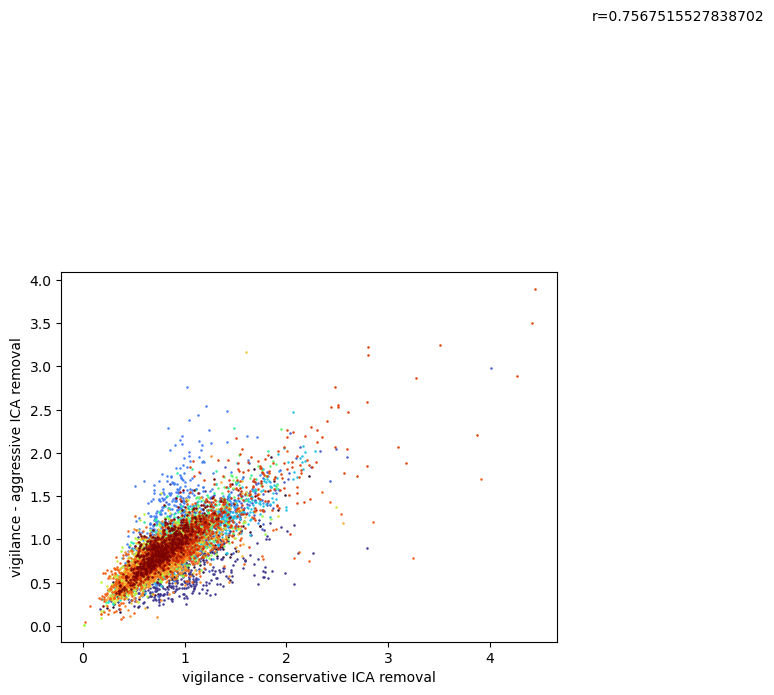

ValueError: All arrays must be of the same length

In [ ]:
# make some plots
import matplotlib as mpl
import seaborn as sns
import pandas as pd
cmap = mpl.colormaps['turbo']
colors = cmap(np.linspace(0, 1, len(my_subs)))

from scipy import stats
x = vigilance_ts[:,:,0].flatten()
y = vigilance_ts[:,:,1].flatten()
slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)


# show linear relationship between both cases
fig = plt.figure()
for s_i in range(len(my_subs)):
    plt.plot(vigilance_ts[s_i,:,0],vigilance_ts[s_i,:,1],'o',color=colors[s_i],markersize=0.8)
#plt.axhline(y=rms_thresh, color='r', linestyle='--', linewidth=2, label='outlier threshold')
plt.text(5,7, 'r={}'.format(r_value))
plt.ylabel('vigilance - aggressive ICA removal')
plt.xlabel('vigilance - conservative ICA removal')
plt.show()

# std(vigilance) differences between conservative and aggressive thresholding
vigilance_std = np.std(vigilance_ts,axis=1)
vigilance_mean = np.std(vigilance_ts,axis=1)
good_epochs = bad_epoch_labels < 0.5

sub_list = np.tile(my_subs, (595,1)).T
df0 = pd.DataFrame(
    {
        "Vigilance": vigilance_ts[:,:,0].flatten(),
        "ICA_method":"aggressive",
        "Subject": sub_list.flatten(),
        "Goodness": good_epochs[:,:,0].flatten()
    })
df1 = pd.DataFrame(
    {
        "Vigilance": vigilance_ts[:,:,1].flatten(),
        "ICA_method":"conservative",
        "Subject": sub_list.flatten(),
        "Goodness": good_epochs[:,:,1].flatten()
    })

result_df = pd.concat([df0, df1])
sns.boxplot(data=result_df,y="Vigilance", x="ICA_method", hue="Goodness")
#print(result_df)

std_dev_by_category = result_df.groupby(['Subject','ICA_method','Goodness'])['Vigilance'].std()
#print(std_dev_by_category)
grouped_df = std_dev_by_category.reset_index()
grouped_df.rename(columns={'Vigilance': 'std(Vigilance)'}, inplace=True)
#print(grouped_df)

fig = plt.figure()
sns.boxplot(data=grouped_df,x="ICA_method",y="std(Vigilance)", hue="Goodness")
plt.show()

fig = plt.figure()
sns.boxplot(data=grouped_df,x="ICA_method",y="std(Vigilance)")
plt.show()

Highlight the effects of bad time points on vigilance:

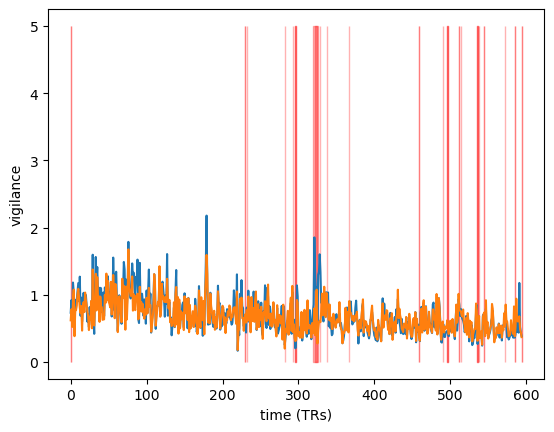

In [ ]:
# plots for vigilance
shp = vigilance_ts[1,:,:].shape

s_n = 0

fig = plt.figure()
plt.plot(vigilance_ts[s_n,:,:])
#plt.plot(good_epochs[1,:,:])
x = np.arange(0,shp[0])
y = 5*np.ones((1,shp[0])).flatten()
plt.fill_between(x, 0, y, where=~good_epochs[s_n,:,1], color='red', alpha=0.3, label='Shaded region')
plt.fill_between(x, 0, y, where=~good_epochs[s_n,:,0], color='red', alpha=0.3, label='Shaded region')
plt.ylabel('vigilance')
plt.xlabel('time (TRs)')
plt.show()
